# Imports and functions

In [ ]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy import linalg as LA
import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

# -----------------------------
# Helpers
# -----------------------------
def to_float01(x):
    x = np.asarray(x)
    if x.dtype.kind in "ui":
        return x.astype(np.float64) / 255.0
    x = x.astype(np.float64)
    x = (x - x.min()) / (x.max() - x.min() + 1e-12)
    return x

def rgb_to_gray(img_rgb):
    # Rec. 709 luma
    r, g, b = img_rgb[..., 0], img_rgb[..., 1], img_rgb[..., 2]
    return 0.2126 * r + 0.7152 * g + 0.0722 * b

def svd_rank_k(A, k):
    """
    Best rank-k approximation via truncated SVD.
    Returns Ak (rank-k) and s (all singular values).
    """
    U, s, Vt = np.linalg.svd(A, full_matrices=False)
    k = int(k)
    Uk = U[:, :k]
    sk = s[:k]
    Vk = Vt[:k, :]
    Ak = (Uk * sk) @ Vk
    return Ak, s

def mape(A, B, eps=1e-3):
    """
    Mean Absolute Percentage Error, stabilized for pixels near 0.
    Uses denominator max(|B|, eps) per element.
    Returns a fraction (e.g., 0.12 = 12%).
    """
    denom = np.maximum(np.abs(B), eps)
    return float(np.mean(np.abs(A - B) / denom))

def approx_storage_bytes_gray(H, W, k, dtype=np.float32):
    """
    Rough storage to store a rank-k approximation for a grayscale image:
      U_k: H*k
      s_k: k
      V_k: k*W
    """
    n_params = H * k + k + k * W
    return n_params * np.dtype(dtype).itemsize

def original_storage_bytes_gray(H, W, dtype=np.float32):
    return H * W * np.dtype(dtype).itemsize

# View compressed images, accuracies, and ratios

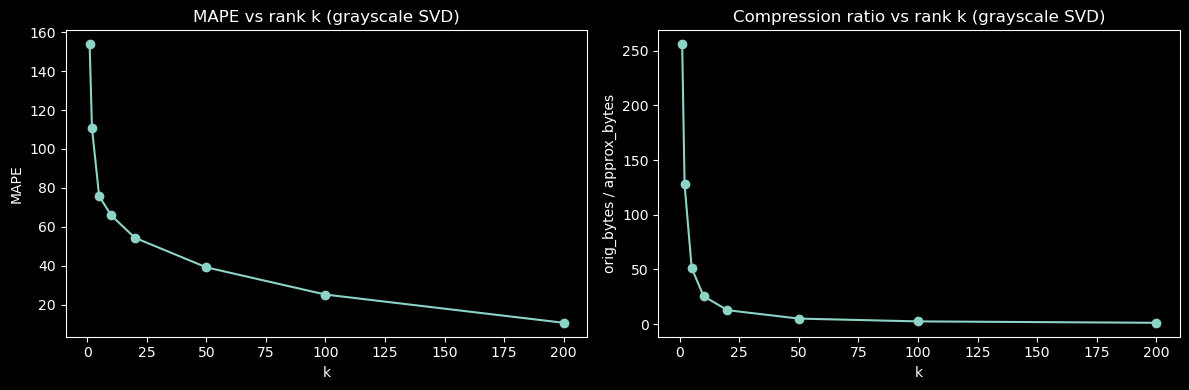

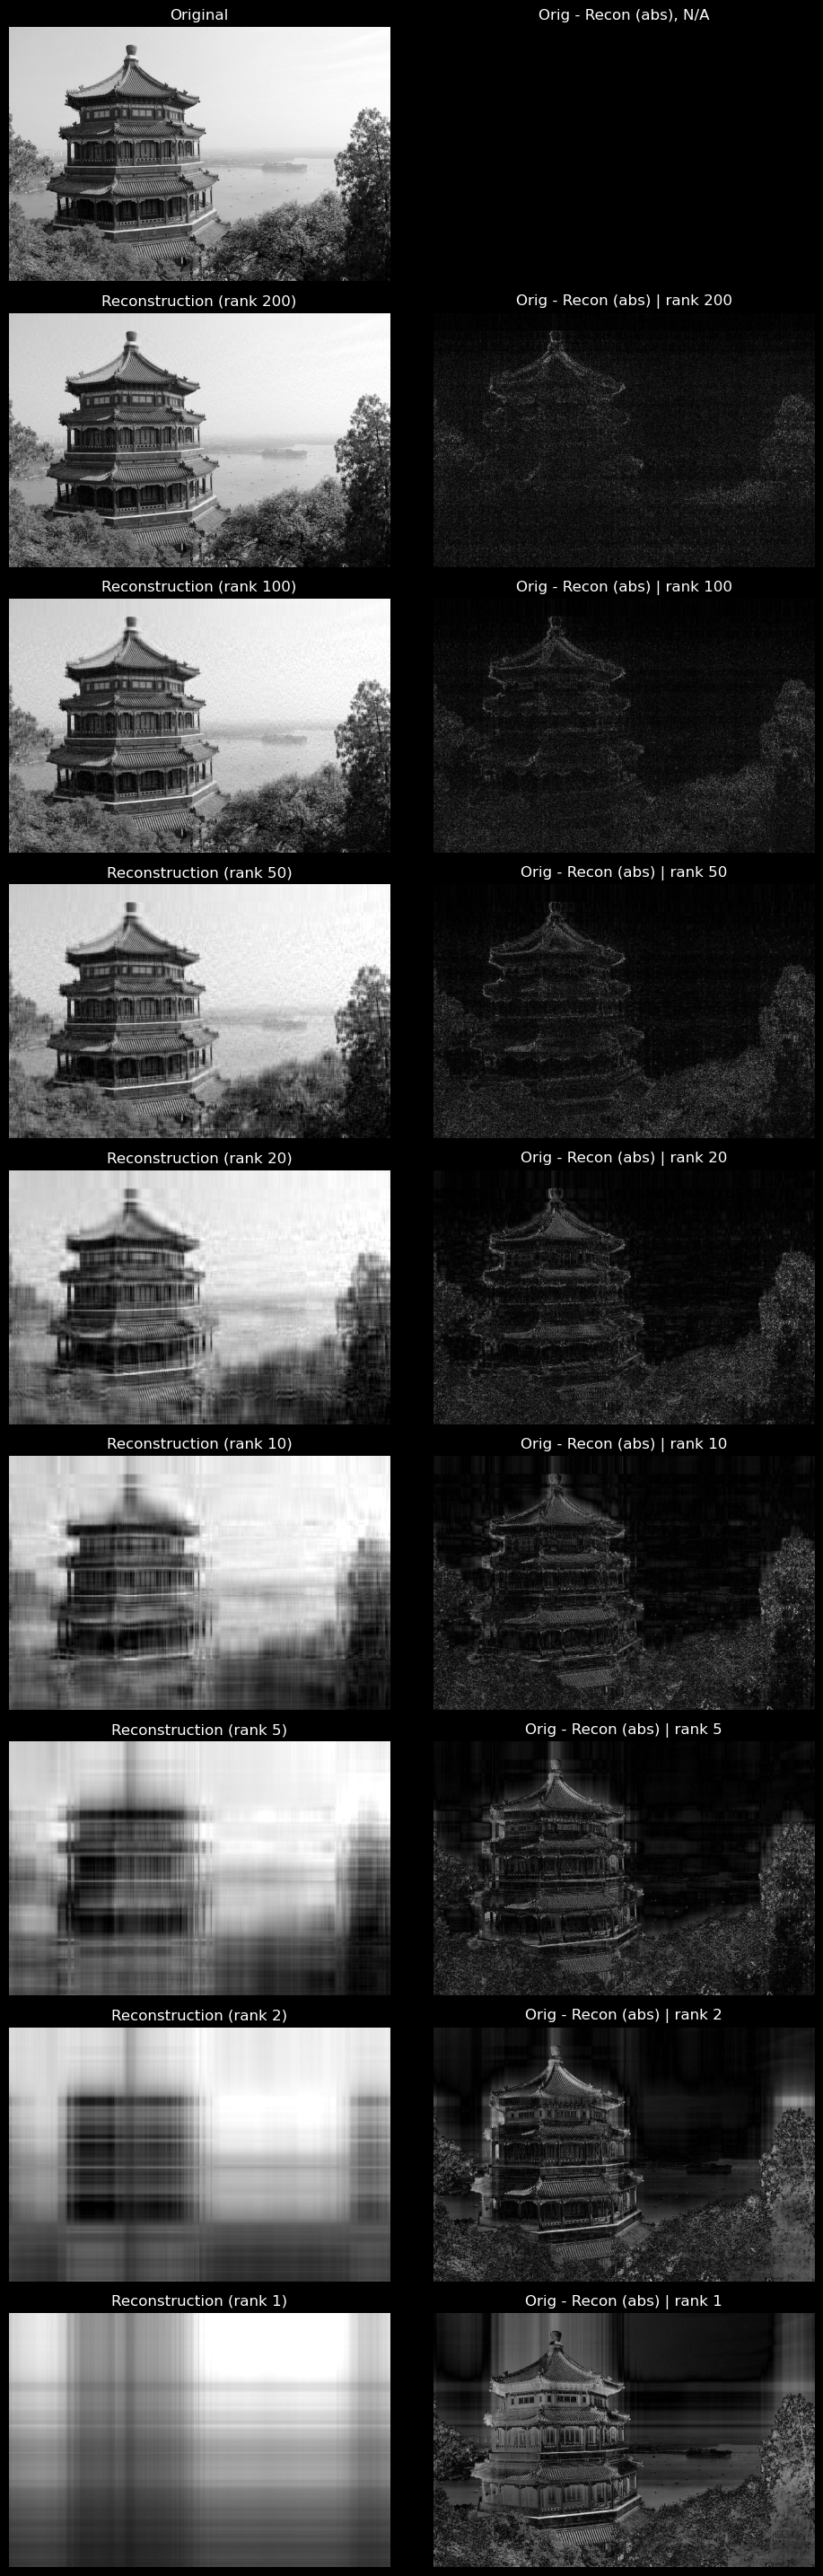

In [ ]:
# -----------------------------
# Load an image (RGB) but compute on grayscale only
# -----------------------------
from sklearn.datasets import load_sample_image
img_rgb = load_sample_image("china.jpg")  # uint8 RGB

img_rgb = to_float01(img_rgb)
gray = rgb_to_gray(img_rgb)
H, W = gray.shape

# -----------------------------
# Choose ranks (edit this list)
# -----------------------------
ks = [1, 2, 5, 10, 20, 50, 100, 200]  # <-- replace with your list
ks = [int(k) for k in ks]
ks = [k for k in ks if 1 <= k <= min(H, W)]
ks_sorted_desc = sorted(ks, reverse=True)
ks_sorted_asc = sorted(ks)

# -----------------------------
# Compute reconstructions + metrics
# -----------------------------
recons = {}
mape_by_k = {}
comp_ratio_by_k = {}

orig_bytes = original_storage_bytes_gray(H, W, np.float32)

for k in ks_sorted_desc:
    Ak, _ = svd_rank_k(gray, k)
    Ak = np.clip(Ak, 0.0, 1.0)
    recons[k] = Ak

    mape_by_k[k] = mape(Ak, gray) * 100

    approx_bytes = approx_storage_bytes_gray(H, W, k, np.float32)
    comp_ratio_by_k[k] = orig_bytes / approx_bytes  # >1 means compression

mape_curve = [mape_by_k[k] for k in ks_sorted_asc]
cr_curve = [comp_ratio_by_k[k] for k in ks_sorted_asc]

# -----------------------------
# Plot MAPE vs k and Compression Ratio vs k (no printing)
# -----------------------------
fig = plt.figure(figsize=(12, 4))

ax1 = plt.subplot(1, 2, 1)
ax1.plot(ks_sorted_asc, mape_curve, marker="o")
ax1.set_title("MAPE vs rank k (grayscale SVD)")
ax1.set_xlabel("k")
ax1.set_ylabel("MAPE")

ax2 = plt.subplot(1, 2, 2)
ax2.plot(ks_sorted_asc, cr_curve, marker="o")
ax2.set_title("Compression ratio vs rank k (grayscale SVD)")
ax2.set_xlabel("k")
ax2.set_ylabel("orig_bytes / approx_bytes")

plt.tight_layout()
plt.show()

# -----------------------------
# Show original + reconstructions:
#   left column: image
#   right column: |orig - recon| (absolute error)
# Sorted: original first, then descending k
# -----------------------------
nrows = 1 + len(ks_sorted_desc)
fig, axes = plt.subplots(nrows=nrows, ncols=2, figsize=(10, 3.2 * nrows))

# Ensure axes is 2D even if nrows=1
axes = np.atleast_2d(axes)

# Row 0: Original + placeholder error (zeros)
axes[0, 0].imshow(gray, cmap="gray", vmin=0, vmax=1)
axes[0, 0].set_title("Original")
axes[0, 0].axis("off")

axes[0, 1].imshow(np.zeros_like(gray), cmap="gray", vmin=0, vmax=1)
axes[0, 1].set_title("Orig - Recon (abs), N/A")
axes[0, 1].axis("off")

# Rows 1..: Reconstructions + abs error
for i, k in enumerate(ks_sorted_desc, start=1):
    rec = recons[k]
    err = np.abs(gray - rec)

    axes[i, 0].imshow(rec, cmap="gray", vmin=0, vmax=1)
    axes[i, 0].set_title(f"Reconstruction (rank {k})")
    axes[i, 0].axis("off")

    # Use its own scale to make error visible; if you want consistent scaling, set vmin=0,vmax=1
    axes[i, 1].imshow(err, cmap="gray")
    axes[i, 1].set_title(f"Orig - Recon (abs) | rank {k}")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

# View individual SVD layers and cumulative reconstruction

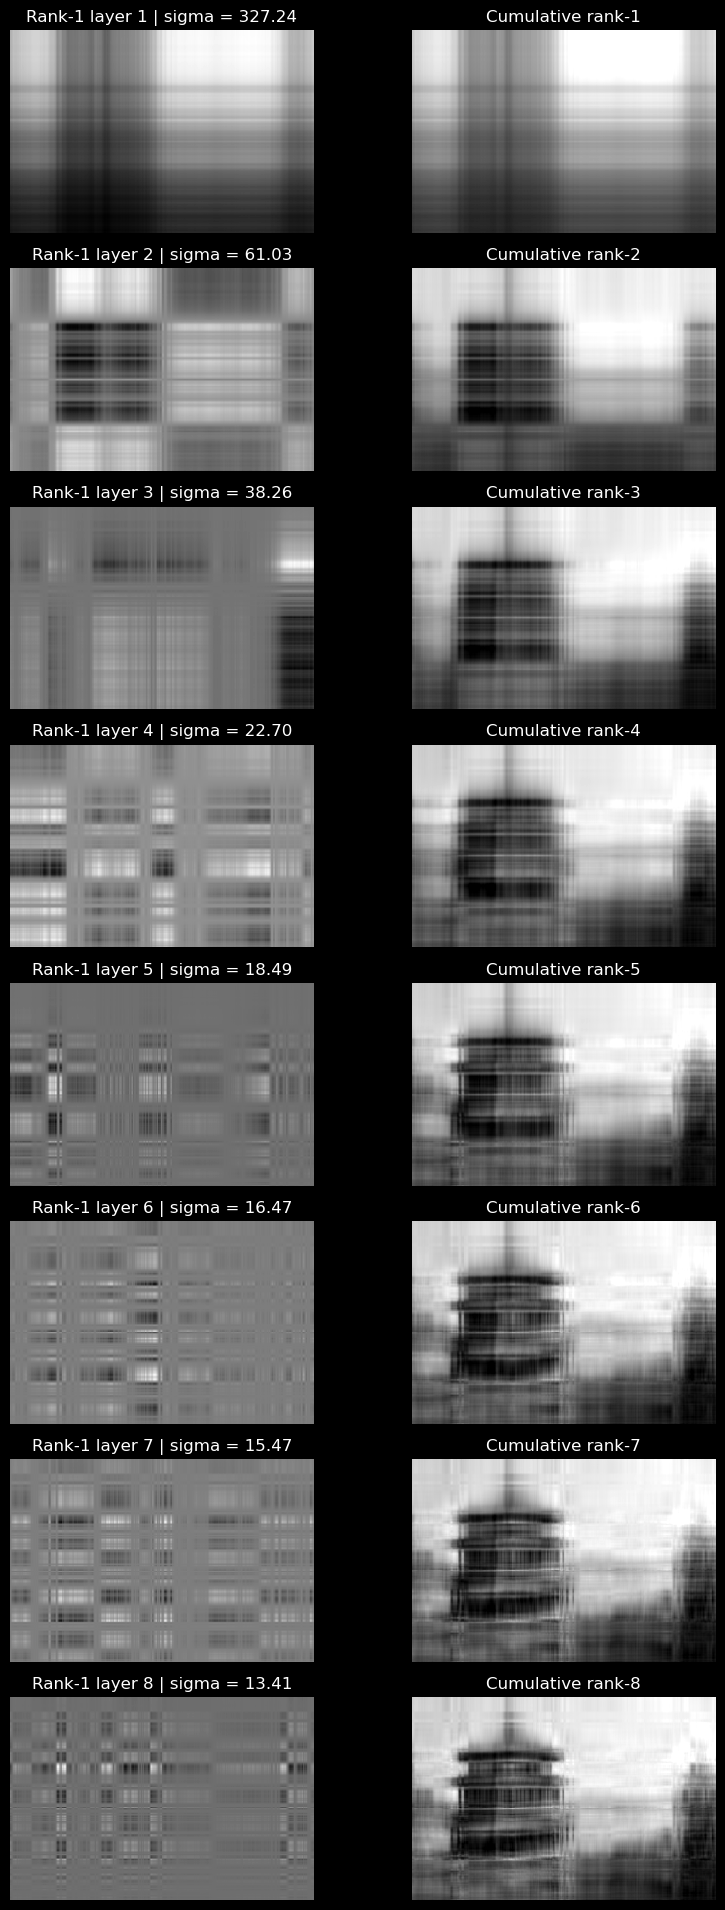

In [7]:
# ---------------------------------------------------------
# Rank-1 SVD image layers
# ---------------------------------------------------------

U, s, Vt = np.linalg.svd(gray, full_matrices=False)

n_layers = 8
layers = [s[i] * np.outer(U[:, i], Vt[i, :]) for i in range(n_layers)]
cumulative = np.cumsum(layers, axis=0)

fig, axes = plt.subplots(n_layers, 2, figsize=(9, 2.4 * n_layers))

for i in range(n_layers):
    axes[i, 0].imshow(layers[i], cmap="gray")
    axes[i, 0].set_title(f"Rank-1 layer {i+1} | sigma = {s[i]:.2f}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(cumulative[i], cmap="gray", vmin=0, vmax=1)
    axes[i, 1].set_title(f"Cumulative rank-{i+1}")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()